## TW r8fin Project

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

### data prep

In [2]:
# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'{symbol}_combined_result.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('merged_r8fin_trades.parquet')

In [3]:
trading_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,order_text,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label
0,2024-09-16,2024-09-13 07:15:38.351,NaT,2024-09-13 03:15:38.351,574483.0,550692610,7024116908,696111430.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
1,2024-09-16,2024-09-13 07:15:38.360,NaT,2024-09-13 03:15:38.360,574483.0,550692610,7024116908,696111431.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
2,2024-09-16,2024-09-13 07:15:39.964,NaT,2024-09-13 03:15:39.964,574483.0,550692629,7024116908,696111455.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
3,2024-09-16,2024-09-13 07:15:40.128,NaT,2024-09-13 03:15:40.128,574483.0,550692629,7024116908,696111456.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
4,2024-09-16,2024-09-13 07:15:39.963,NaT,2024-09-13 03:15:39.963,574483.0,550692627,7024116908,696111462.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 29@112.921875), -0.737...",Hedge,98.630859,5629609485429684499,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684503,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684505,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 43@112.921875), -0.737...",Hedge,98.630859,5629609485429684507,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades


In [4]:
trading_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label'],
      dtype='object')

In [5]:
trading_data.iloc[0, :]

trade_date                                                   2024-09-16 00:00:00
executiontime                                         2024-09-13 07:15:38.351000
brokerexecutiontime                                                          NaT
exec_time_et                                          2024-09-13 03:15:38.351000
recapid                                                                 574483.0
orderid                                                                550692610
parentcorrelationorderid                                              7024116908
executionid                                                          696111430.0
firm                                                                    ZUMLOTRS
client                                                                  MVXHXVKU
syntheticcontractidentifier                               SC10091306372236346472
instrument                                                 Z XM ROLL 1.8% FRONTS
syntheticpricemode          

In [6]:
# Convert execution time to datetime format
trading_data['executiontime'] = pd.to_datetime(trading_data['executiontime'])

# Round execution time down to the nearest 10 seconds
trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')

# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

# Filter the trading data to include only rows with the selected maturity symbols
filtered_trading_data = trading_data[trading_data['symbol'].isin(maturity_symbols)]

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_19174/910274529.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')


In [7]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
market_symbols = ['30yr', '5yr', '2yr', '10yr', '3yr', '7yr', '20yr']

# Create a mapping between trading symbols and market symbols
symbol_mapping = dict(zip(maturity_symbols, market_symbols))

# Create an empty list to store merged data for each symbol
merged_data_list = []

# Loop through each symbol and merge with corresponding market data
for maturity_symbol, market_symbol in symbol_mapping.items():
    # Filter trading data for the current symbol
    trading_data_filtered = filtered_trading_data[filtered_trading_data['symbol'] == maturity_symbol]
    market_data_filtered = market_data[market_symbol].copy()

    # Convert market data time to datetime format
    market_data_filtered['time'] = pd.to_datetime(market_data_filtered['time'])

    # Merge trading data with market data based on exact match of time, including bid/ask size and price
    merged_data = pd.merge(trading_data_filtered, market_data_filtered,
                           left_on='executiontime_10s', right_on='time',
                           how='left')

    # Append merged data to the list
    merged_data_list.append(merged_data)

In [8]:
# Concatenate all merged data
mapped_data = pd.concat(merged_data_list, ignore_index=True)
mapped_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,build_name,hide_duration,pop_ticks,label,executiontime_10s,time,bid_size,bid_price,ask_size,ask_price
0,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,None,NaN,None,r8fin_trades,2024-09-16 06:32:30,2024-09-16 06:32:30,7.0,104.734375,3.0,104.828125
1,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,None,NaN,None,r8fin_trades,2024-09-16 06:32:50,2024-09-16 06:32:50,5.0,104.687500,2.0,104.796875
2,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,None,NaN,None,r8fin_trades,2024-09-16 06:33:00,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375
3,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,None,NaN,None,r8fin_trades,2024-09-16 06:33:00,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375
4,2024-09-16,2024-09-16 06:43:56.053,2024-09-16 06:43:56.052,2024-09-16 02:43:56.052,575369.0,7024415027,7024411965,696312874.0,UZIZISKH,IPRLWHII,...,Default,300.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0, comp_3:...",r8fin_trades,2024-09-16 06:43:50,2024-09-16 06:43:50,6.0,104.734375,1.0,105.625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1818371,2024-10-04,2024-10-04 20:57:50.936,2024-10-04 20:57:50.934,2024-10-04 16:57:50.934,590546.0,7029292130,7029287470,699616752.0,FDAUTWEA,JIWMFDHM,...,H-MOD,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:57:50,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375
1818372,2024-10-04,2024-10-04 20:57:59.989,2024-10-04 20:57:59.987,2024-10-04 16:57:59.987,590546.0,7029292285,7029287470,699616782.0,FDAUTWEA,JIWMFDHM,...,H-MOD,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:57:50,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375
1818373,2024-10-04,2024-10-04 20:58:15.156,2024-10-04 20:58:15.155,2024-10-04 16:58:15.155,590546.0,7029292347,7029287470,699616825.0,FDAUTWEA,JIWMFDHM,...,H-MOD,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:58:10,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375
1818374,2024-10-04,2024-10-04 20:58:15.184,2024-10-04 20:58:15.182,2024-10-04 16:58:15.182,590546.0,7029292354,7029287470,699616826.0,FDAUTWEA,JIWMFDHM,...,H-MOD,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:58:10,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375


In [9]:
mapped_data.iloc[0,:]

trade_date                            2024-09-16 00:00:00
executiontime                  2024-09-16 06:32:33.514000
brokerexecutiontime            2024-09-16 06:32:33.512000
exec_time_et                   2024-09-16 02:32:33.512000
recapid                                          575316.0
orderid                                        7024412350
parentcorrelationorderid                       7024412350
executionid                                   696312820.0
firm                                             PWLPLFJQ
client                                           PWOBVWCE
syntheticcontractidentifier                          None
instrument                                    UST 30_YEAR
syntheticpricemode                                   None
syntheticticksize                                     NaN
syntheticcontractdefinition                          None
security_type                                           C
symbol                                            30 Year
cusip         

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_19174/3053070026.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  price_variation_bins = mapped_data['price_variation'].resample('10S').sum().reset_index()


Price Variation Analysis:
    executiontime_10s  price_variation
0 2024-08-04 23:44:40        -0.018555
1 2024-08-04 23:44:50         0.000000
2 2024-08-04 23:45:00         1.964844
3 2024-08-04 23:45:10        -0.003906
4 2024-08-04 23:45:20         0.000000
Correlation with Quantity: nan


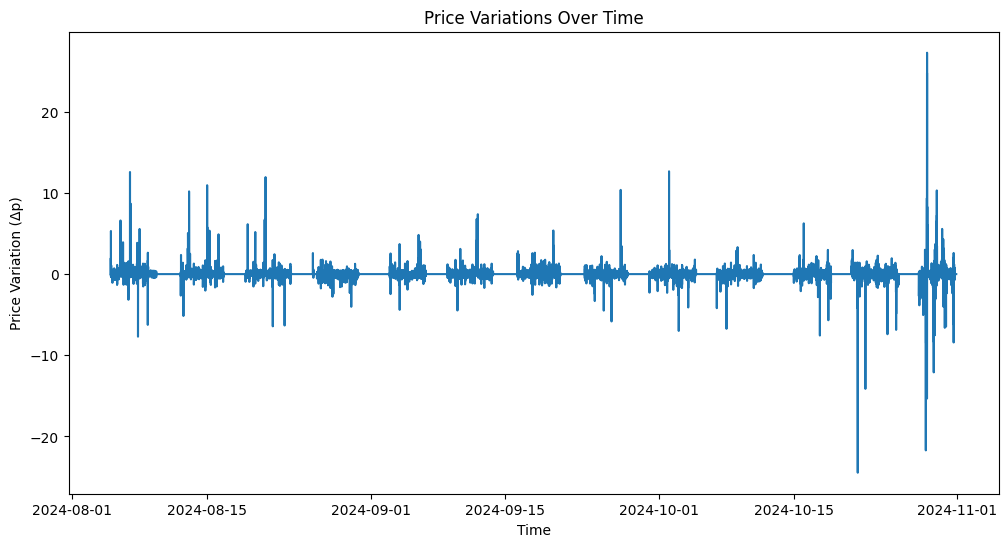

In [10]:
# Sample data (assuming your dataset is in a DataFrame called df)
mapped_data['mid_price'] = (mapped_data['bid_price'] + mapped_data['ask_price']) / 2

# Calculate price variation (Δp)
mapped_data['price_variation'] = mapped_data['mid_price'].diff()

# Optional: Aggregate by 10-second bins or other intervals
mapped_data.set_index('executiontime_10s', inplace=True)
price_variation_bins = mapped_data['price_variation'].resample('10S').sum().reset_index()

# Add additional feature analysis if needed
# Example: Correlation with 'quantity'
correlation = price_variation_bins['price_variation'].corr(mapped_data['quantity'])

# Output results
print("Price Variation Analysis:")
print(price_variation_bins.head())

print(f"Correlation with Quantity: {correlation}")

# Visualize price variation
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(price_variation_bins['executiontime_10s'], price_variation_bins['price_variation'])
plt.title('Price Variations Over Time')
plt.xlabel('Time')
plt.ylabel('Price Variation (Δp)')
plt.show()

In [11]:
mapped_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,hide_duration,pop_ticks,label,time,bid_size,bid_price,ask_size,ask_price,mid_price,price_variation
executiontime_10s,,,,,,,,,,,,,,,,,,,,,
2024-09-16 06:32:30,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,NaN,None,r8fin_trades,2024-09-16 06:32:30,7.0,104.734375,3.0,104.828125,104.781250,NaN
2024-09-16 06:32:50,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,NaN,None,r8fin_trades,2024-09-16 06:32:50,5.0,104.687500,2.0,104.796875,104.742188,-0.039062
2024-09-16 06:33:00,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,NaN,None,r8fin_trades,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375,104.804688,0.062500
2024-09-16 06:33:00,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,NaN,None,r8fin_trades,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375,104.804688,0.000000
2024-09-16 06:43:50,2024-09-16,2024-09-16 06:43:56.053,2024-09-16 06:43:56.052,2024-09-16 02:43:56.052,575369.0,7024415027,7024411965,696312874.0,UZIZISKH,IPRLWHII,...,300.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0, comp_3:...",r8fin_trades,2024-09-16 06:43:50,6.0,104.734375,1.0,105.625000,105.179688,0.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-04 20:57:50,2024-10-04,2024-10-04 20:57:50.936,2024-10-04 20:57:50.934,2024-10-04 16:57:50.934,590546.0,7029292130,7029287470,699616752.0,FDAUTWEA,JIWMFDHM,...,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375,97.492188,0.000000
2024-10-04 20:57:50,2024-10-04,2024-10-04 20:57:59.989,2024-10-04 20:57:59.987,2024-10-04 16:57:59.987,590546.0,7029292285,7029287470,699616782.0,FDAUTWEA,JIWMFDHM,...,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375,97.492188,0.000000
2024-10-04 20:58:10,2024-10-04,2024-10-04 20:58:15.156,2024-10-04 20:58:15.155,2024-10-04 16:58:15.155,590546.0,7029292347,7029287470,699616825.0,FDAUTWEA,JIWMFDHM,...,35.0,"comp_0: 2.0, comp_1: 0.0",r8fin_trades,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375,97.492188,0.000000


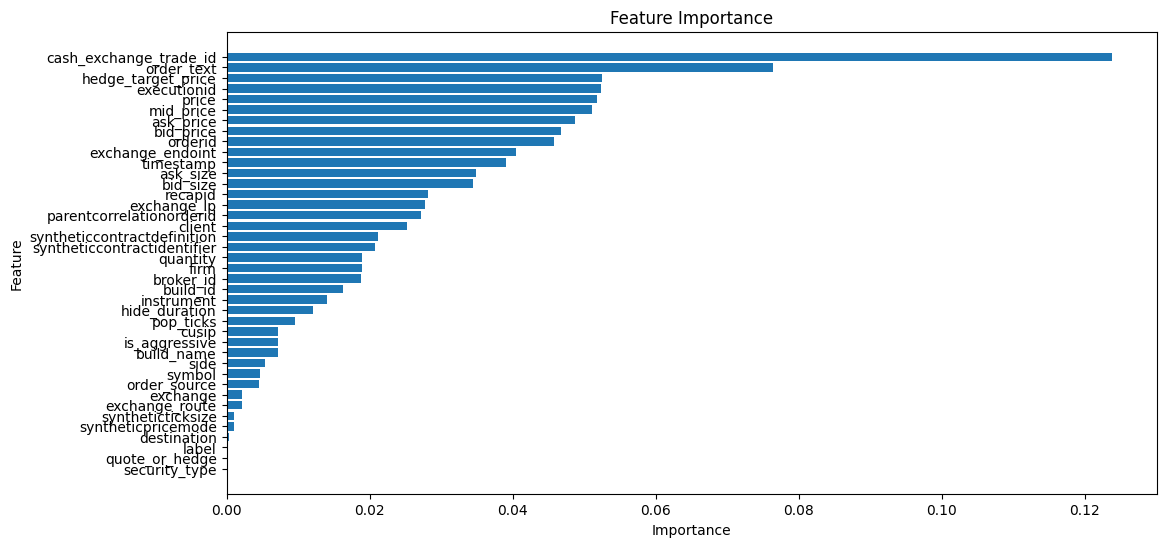

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load and preprocess data
mapped_data['mid_price'] = (mapped_data['bid_price'] + mapped_data['ask_price']) / 2
mapped_data['price_variation'] = mapped_data['mid_price'].diff()

# Encode categorical features
categorical_cols = mapped_data.select_dtypes(include=['object']).columns
encoder = LabelEncoder()
for col in categorical_cols:
    mapped_data[col] = encoder.fit_transform(mapped_data[col].astype(str))

# Drop rows with NaN values
mapped_data.dropna(inplace=True)

# Define features (X) and target (y)
X = mapped_data.drop(columns=['price_variation', 'trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et', 'time'])
y = mapped_data['price_variation'].apply(lambda x: 1 if x > 0 else 0)  # Binary target: price increased or not

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Feature importance
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [22]:
X.iloc[0, :]

recapid                        5.754340e+05
orderid                        7.024448e+09
parentcorrelationorderid       7.024448e+09
executionid                    6.963410e+08
firm                           4.400000e+01
client                         2.670000e+02
syntheticcontractidentifier    2.064000e+03
instrument                     6.400000e+02
syntheticpricemode             2.000000e+00
syntheticticksize              1.000000e-02
syntheticcontractdefinition    1.281000e+03
security_type                  0.000000e+00
symbol                         4.000000e+00
cusip                          2.000000e+00
side                           1.000000e+00
quantity                       1.000000e+00
price                          1.046973e+02
order_source                   0.000000e+00
broker_id                      1.400000e+01
exchange                       6.000000e+00
exchange_route                 1.000000e+00
exchange_endoint               2.300000e+01
exchange_lp                    1